In [5]:
import os
import cv2
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score, RocCurveDisplay, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer,LabelEncoder, label_binarize
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.svm import LinearSVC


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential, save_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from keras.applications import DenseNet121
from sklearn.metrics import roc_curve, auc

from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from keras.backend import clear_session
import gc


In [6]:
# Load the labels CSV files
train_labels = pd.read_csv(r'/Users/bytes/Desktop/facial_emotion_recognition/train_labels.csv')
test_labels = pd.read_csv(r'/Users/bytes/Desktop/facial_emotion_recognition/test_labels.csv')

# Display the first few rows of the train labels to check the structure
print(train_labels.head())

classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']


label_map = {label: (idx+1) for idx, label in enumerate(classes)}

print(label_map)

                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5
{'surprise': 1, 'fear': 2, 'disgust': 3, 'happy': 4, 'sad': 5, 'angry': 6, 'neutral': 7}


In [7]:
# Function to load images and labels from the directory
def load_data(dataset_dir, label_map):
    images = []
    labels = []
    
    for label, idx in tqdm(label_map.items()):
        folder_path = os.path.join(dataset_dir, str(idx))  # +1 because folder names start from '1'
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img_rgb)
            labels.append(idx)
        
    
    return np.array(images), np.array(labels)

# Load train and test datasets
train_images, train_labels = load_data(r'/Users/bytes/Desktop/facial_emotion_recognition/DATASET/train', label_map)
test_images, test_labels = load_data(r'/Users/bytes/Desktop/facial_emotion_recognition/DATASET/test', label_map)
print(train_images.shape)
print(test_images.shape)


100%|██████████| 7/7 [00:00<00:00, 13.16it/s]

(12271, 100, 100, 3)
(3068, 100, 100, 3)


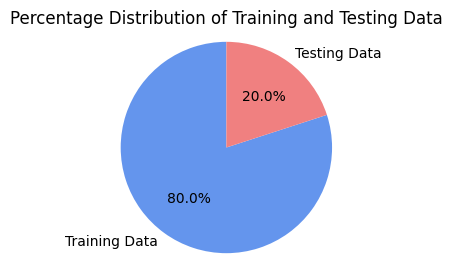

In [8]:
# Calculate the total number of images
total_images = len(train_images) + len(test_images)

# Calculate percentages
train_percentage = (len(train_images) / total_images) * 100
test_percentage = (len(test_images) / total_images) * 100

# Data for pie chart
labels = ['Training Data', 'Testing Data']
sizes = [train_percentage, test_percentage]
colors = ['cornflowerblue', 'lightcoral']

# Plot the pie chart
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage Distribution of Training and Testing Data')
plt.axis('equal')  
plt.show()


train_label_counts  Counter({np.int64(4): 4772, np.int64(7): 2524, np.int64(5): 1982, np.int64(1): 1290, np.int64(3): 717, np.int64(6): 705, np.int64(2): 281})
test_counts [329, 74, 160, 1185, 478, 162, 680]


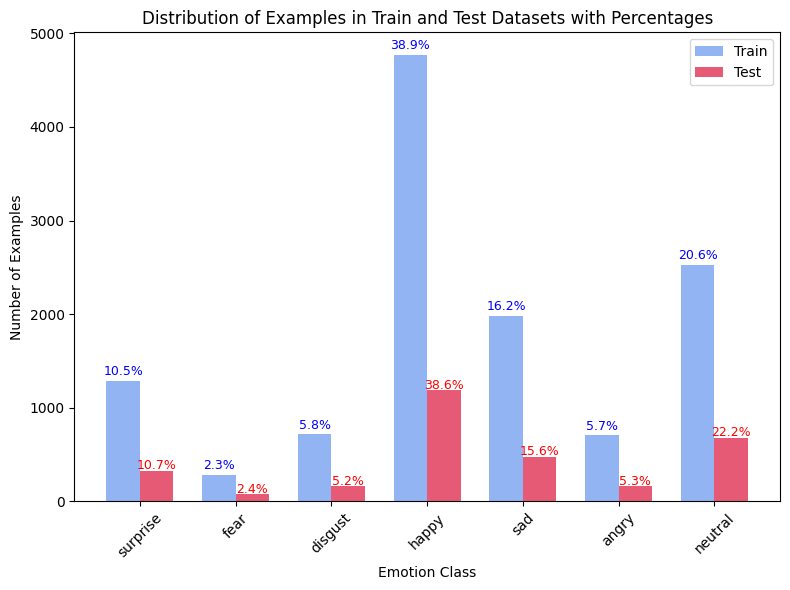

In [9]:
# Count the distribution of classes in train and test datasets
train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)
print('train_label_counts ',train_label_counts)
# Convert to sorted lists for plotting
train_classes = sorted(train_label_counts.keys())
train_counts = [train_label_counts[cls] for cls in train_classes]

test_classes = sorted(test_label_counts.keys())
test_counts = [test_label_counts[cls] for cls in test_classes]
print('test_counts',test_counts)
# Calculate the total number of examples in train and test datasets
total_train = sum(train_counts)
total_test = sum(test_counts)

# Calculate percentages for train and test datasets
train_percentages = [(count / total_train) * 100 for count in train_counts]
test_percentages = [(count / total_test) * 100 for count in test_counts]

# Plot the distribution with percentages
plt.figure(figsize=(8, 6))
x = range(len(classes))
bar_width = 0.35

plt.bar(x, train_counts, width=bar_width, label="Train", alpha=0.7, color="cornflowerblue")
plt.bar([p + bar_width for p in x], test_counts, width=bar_width, label="Test", alpha=0.7, color="crimson")

# Annotate percentages on bars
for i, (train_count, test_count) in enumerate(zip(train_counts, test_counts)):
    plt.text(i, train_count + 0.005 * total_train, f"{train_percentages[i]:.1f}%", ha='center', color="blue", fontsize=9)
    plt.text(i + bar_width, test_count + 0.005 * total_test, f"{test_percentages[i]:.1f}%", ha='center', color="red", fontsize=9)

# Add labels and title
plt.xticks([p + bar_width / 2 for p in x], classes, rotation=45)
plt.xlabel("Emotion Class")
plt.ylabel("Number of Examples")
plt.title("Distribution of Examples in Train and Test Datasets with Percentages")
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [10]:
# Combine the train and test datasets into the same variables
X_train = np.concatenate([train_images, test_images], axis=0)
Y_train = np.concatenate([train_labels, test_labels], axis=0)

# Display the shapes to confirm
print(X_train.shape)
print(Y_train.shape)

(15339, 100, 100, 3)
(15339,)


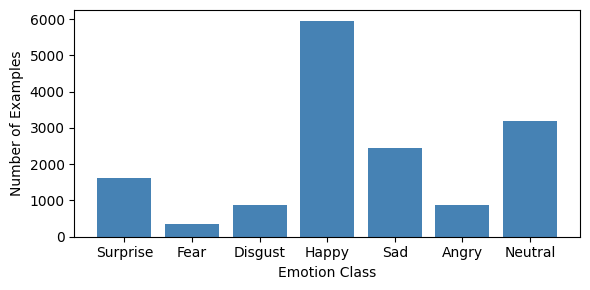

In [11]:
# Count the distribution of classes in the resampled train dataset
train_label_counts_resampled = Counter(Y_train)
    
# Convert to sorted lists for plotting
train_classes_resampled = sorted(train_label_counts_resampled.keys())
train_counts_resampled = [train_label_counts_resampled[cls] for cls in train_classes_resampled]
# Plot the distribution
plt.figure(figsize=(6, 3))
x_labels = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
    
# Bar plot for the resampled distribution
plt.bar(x_labels, train_counts_resampled, color="steelblue")
    
# Add labels and title
plt.xlabel("Emotion Class")
plt.ylabel("Number of Examples")
plt.title('')
plt.tight_layout()
    
# Show the plot
plt.show()

In [12]:
# Shuffle X_train and Y_train
X_train, Y_train = shuffle(X_train, Y_train, random_state=42)

# Display the shapes to confirm the data is shuffled
print(X_train.shape)
print(Y_train.shape)

(15339, 100, 100, 3)
(15339,)


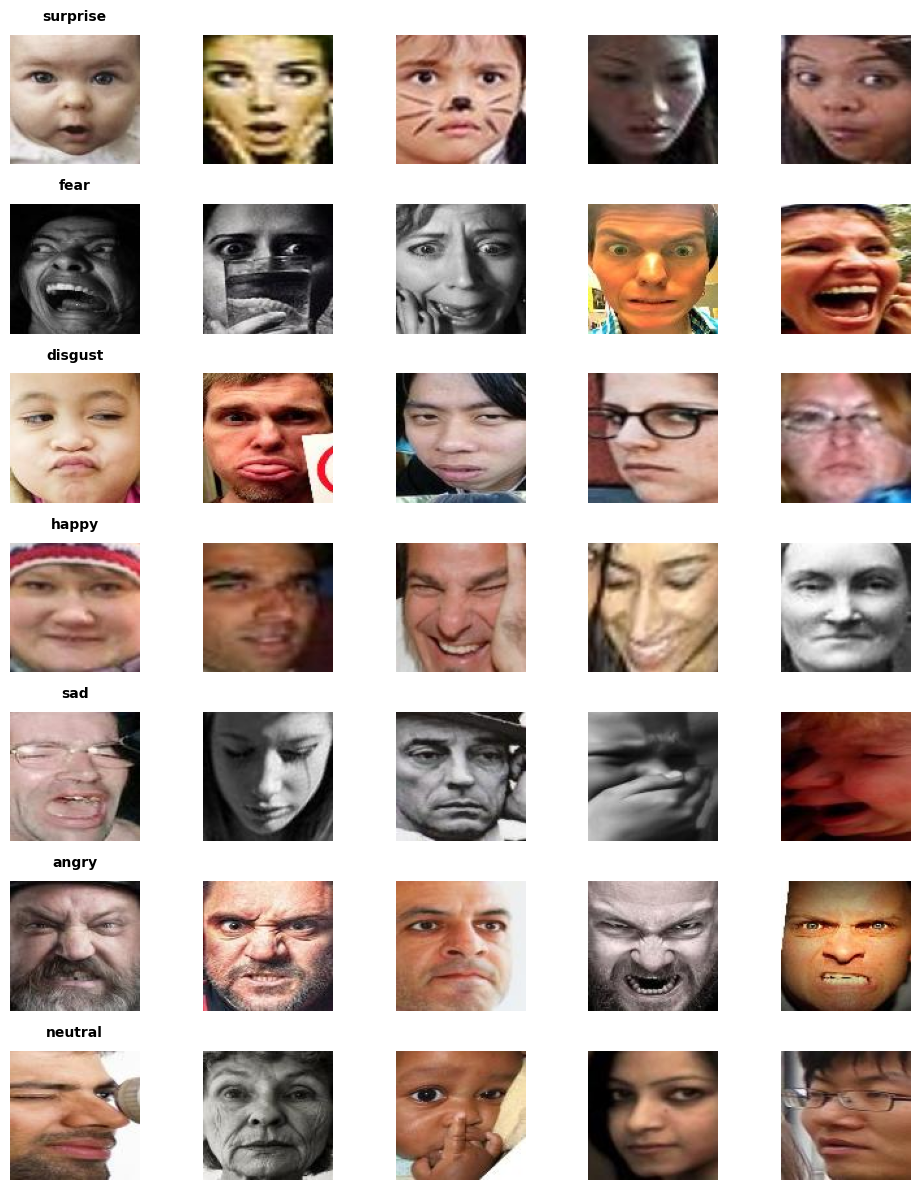

In [13]:
def show_examples(train_images, train_labels, labels, num_examples=5):
    num_classes = len(classes)
    fig, axs = plt.subplots(num_classes, num_examples, figsize=(10, 12))
    
    for i, class_name in enumerate(classes):
        class_indices = [idx for idx, label in enumerate(train_labels) if label == i+1]
        selected_indices = np.random.choice(class_indices, num_examples, replace=False)
        axs[i, 0].set_title(class_name, fontsize=10, pad=10, fontweight='bold')
        # Display the random images for the current class
        for j, idx in enumerate(selected_indices):
            img = train_images[idx]
            axs[i, j].imshow(img)
            axs[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show sample images for each class
show_examples(X_train, Y_train, classes)

In [14]:
# most frequent image sizes :
train_data_shapes = []
for img in X_train:
  train_data_shapes.append(img.shape)
# Count occurrences for each size
shape_counts = {}
for shape in train_data_shapes:
  if shape not in shape_counts:
    shape_counts[shape] = 0
  shape_counts[shape] += 1
# Sort shapes by count
sorted_shapes = sorted(shape_counts.items(), key=lambda x: x[1], reverse=True)
# show most frequent size
print("Most frequent Train images shapes:")
for shape, count in sorted_shapes[:3]:
  print(f"- {shape}: {count}")

Most frequent Train images shapes:
- (100, 100, 3): 15339


# <p style="color:white;background-color:#E17A8A;font-family:newtimeroman;font-size:130%;text-align:center;border-radius:50px 10px;">data preparation</p>




In [17]:
# Function to plot the class distribution
def plot_class_distribution(y, title):
    # Count the distribution of classes in the resampled train dataset
    train_label_counts_resampled = Counter(y)
    
    # Convert to sorted lists for plotting
    train_classes_resampled = sorted(train_label_counts_resampled.keys())
    train_counts_resampled = [train_label_counts_resampled[cls] for cls in train_classes_resampled]
    
    # Plot the distribution
    plt.figure(figsize=(6, 3))
    x_labels = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
    
    # Bar plot for the resampled distribution
    plt.bar(x_labels, train_counts_resampled, color="steelblue")
    
    # Add labels and title
    plt.xlabel("Emotion Class")
    plt.ylabel("Number of Examples")
    plt.title(title)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

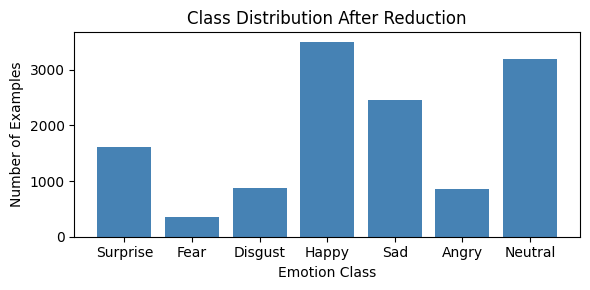

In [18]:
# Function to reduce the size of a specific class in the dataset
def reduce_class(X, y, target_class, target_size):
    # Separate the target class
    class_indices = np.where(y == target_class)[0]
    non_class_indices = np.where(y != target_class)[0]
    
    # Randomly sample the target class to the desired size
    reduced_class_indices = np.random.choice(class_indices, target_size, replace=False)
    
    # Combine the reduced class with the other classes
    final_indices = np.concatenate([reduced_class_indices, non_class_indices])
    X_reduced = X[final_indices]
    y_reduced = y[final_indices]
    
    return X_reduced, y_reduced

target_class = 4  # The 'happy' class
target_size = 3500
X_train_reduced, y_train_reduced = reduce_class(X_train, Y_train, target_class, target_size)
# Plot the new distribution after reduction
plot_class_distribution(y_train_reduced, "Class Distribution After Reduction")

Class 1: 1619 samples, generating 1881 more.
Class 2: 355 samples, generating 3145 more.
Class 3: 877 samples, generating 2623 more.
Class 5: 2460 samples, generating 1040 more.
Class 6: 867 samples, generating 2633 more.
Class 7: 3204 samples, generating 296 more.


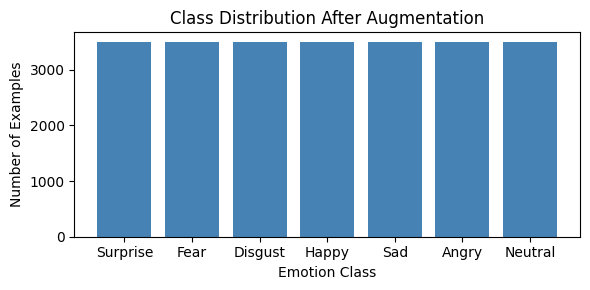

In [19]:
def augment_classes(images, labels, target_counts):
    # Initialize the image augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=10,             # Random rotation between -10 to 10 degrees
        width_shift_range=0.1,         # Random horizontal shift
        height_shift_range=0.1,        # Random vertical shift
        zoom_range=0.1,                # Random zoom
        vertical_flip=False,           # No vertical flip
        horizontal_flip=True,          # Random horizontal flip
        channel_shift_range=50.0,      # Random change in channel values
        fill_mode='nearest'            # Fill in new pixels using the nearest value
    )

    augmented_images = images.copy()  # Copy images to keep originals intact
    augmented_labels = labels.copy()  # Same for labels

    # For each class, increase the number of samples if needed
    for target_class, target_count in target_counts.items():
        # Filter images and labels for the current target class
        class_images = images[labels == target_class]
        class_labels = labels[labels == target_class]
        # Calculate how many new samples we need
        augment_count = target_count - len(class_images)

        if augment_count > 0:
            print(f'Class {target_class}: {len(class_images)} samples, generating {augment_count} more.')

            # Prepare lists to hold augmented images and labels
            class_images_augmented = []
            class_labels_augmented = []

            # Generate augmented samples iteratively
            for batch in datagen.flow(class_images, batch_size=1, seed=42):
                aug_image = batch[0].astype(np.uint8)
                class_images_augmented.append(aug_image)
                class_labels_augmented.append(target_class)
                
                # Stop when we've generated enough
                if len(class_images_augmented) >= augment_count:
                    break
            
            # Add the new samples to the original dataset
            augmented_images = np.vstack((augmented_images, np.array(class_images_augmented)))
            augmented_labels = np.hstack((augmented_labels, np.array(class_labels_augmented)))

    return augmented_images, augmented_labels

# Example usage
target_counts = {1: 3500, 2: 3500, 3: 3500, 5: 3500, 6: 3500, 7: 3500}  # Desired number of samples per class
X_train_augmented, y_train_augmented = augment_classes(X_train_reduced, y_train_reduced, target_counts)

# Visualize the class distribution after augmentation
plot_class_distribution(y_train_augmented, "Class Distribution After Augmentation")


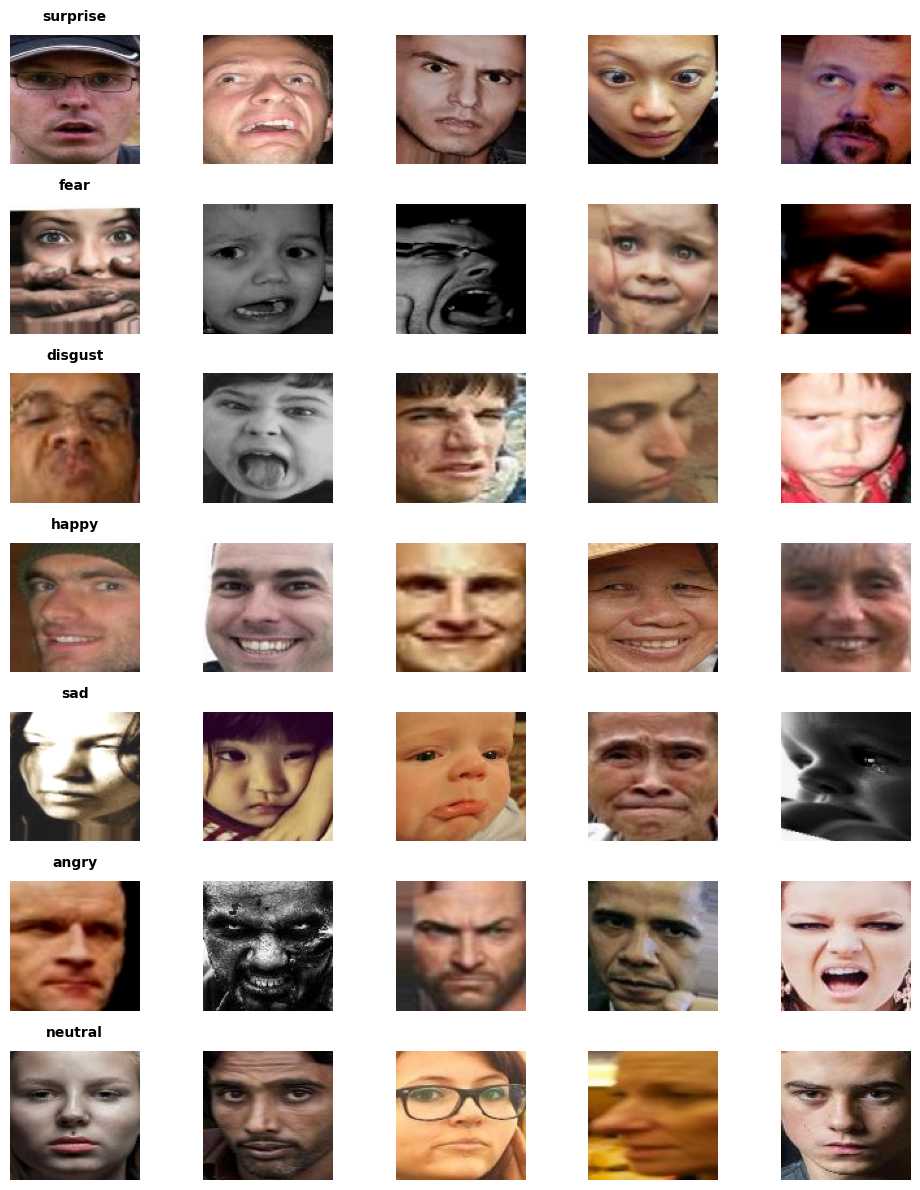

In [20]:
# Show sample images for each class
show_examples(X_train_augmented, y_train_augmented, classes)

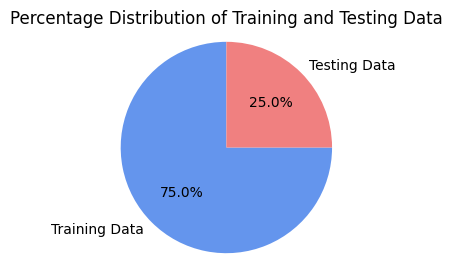

In [21]:
# Split the data into training and testing sets (75% train, 25% test)
X_train, X_test, Y_train, Y_test = train_test_split(X_train_augmented, 
                                                    y_train_augmented, 
                                                    test_size=0.25, 
                                                    shuffle=True,
                                                    random_state=42)

# Calculate the total number of images
total_images = len(X_train) + len(X_test)

# Calculate percentages
train_percentage = (len(X_train) / total_images) * 100
test_percentage = (len(X_test) / total_images) * 100

# Data for pie chart
labels = ['Training Data', 'Testing Data']
sizes = [train_percentage, test_percentage]
colors = ['cornflowerblue', 'lightcoral']

# Plot the pie chart
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage Distribution of Training and Testing Data')
plt.axis('equal')  
plt.show()


In [22]:
from sklearn.model_selection import train_test_split

# Split training data into new train and validation sets (e.g., 10% validation)
X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train, Y_train, test_size=0.1, random_state=42, stratify=Y_train
)


In [23]:
def normalize_images(images):
    # Normalize pixel values to [0, 1]
    return images / 255.0
train_images_normalized = normalize_images(X_train_final)
val_images_normalized = normalize_images(X_val)
test_images_normalized = normalize_images(X_test)


def reshape_images_for_cnn(images):
    # Reshape images to (height, width, channels) for CNN
    return images.reshape((images.shape[0], 100, 100, 3))

train_images_CNNreshaped = reshape_images_for_cnn(train_images_normalized)
val_images_CNNreshaped = reshape_images_for_cnn(val_images_normalized)
test_images_CNNreshaped = reshape_images_for_cnn(test_images_normalized)


In [24]:
Y_train_cat = to_categorical(Y_train_final - 1, num_classes=len(classes))
Y_val_cat = to_categorical(Y_val - 1, num_classes=len(classes))
Y_test_cat = to_categorical(Y_test - 1, num_classes=len(classes))


In [25]:
datagen = ImageDataGenerator(
    rotation_range=20,             
    width_shift_range=0.1,         
    height_shift_range=0.1,  
    vertical_flip=False,               
    horizontal_flip=True, 
    fill_mode='nearest'
)
train_generator = datagen.flow(train_images_CNNreshaped, Y_train_cat, batch_size=64)